In [19]:
from ase.io import read
import numpy as np
from scipy.ndimage import gaussian_filter
import os
import MDAnalysis as mda
from latexfig import LatexFigure

In [34]:
def calculate_displacements(dir, temperatures, Nsc=None):

    if Nsc is None:
        unit_cell = read(os.path.join(dir, 'unitcell.xyz')).get_cell()
        super_cell = read(os.path.join(dir, 'supercell.xyz')).get_cell()
        sc_matrix = np.diag(super_cell.diagonal() / unit_cell.diagonal())
        sc_matrix = np.round(sc_matrix, 1).astype(int)
    else:
        sc_matrix = np.diag(Nsc)
    
    # If the last element in the diagonal is 1, then we have a slab
    if sc_matrix.diagonal()[-1] == 1:
        bulk = False
    else:
        bulk = True

    all_frac_in_uc = {temp: [] for temp in temperatures}
    all_pos_in_uc = {temp: [] for temp in temperatures}
    times = []

    for i, temp in enumerate(temperatures):
        mdtraj = mda.Universe(os.path.join(dir, temp, 'model.xyz'),
                              os.path.join(dir, temp, 'movie.nc'),
                              in_memory=False, in_memory_step=1)
        elements = ['Ba', 'O', 'Ti']
        all_frac_in_uc[temp] = {element: [] for element in elements}
        all_pos_in_uc[temp] = {element: [] for element in elements}
        
        for j, element in enumerate(elements):
            atoms = mdtraj.select_atoms(f'element {element}')
            all_frac_in_uc[temp][element] = []
            all_pos_in_uc[temp][element] = []
            for ts in mdtraj.trajectory[1:]:
                effective_sc = ts.triclinic_dimensions
                if not bulk:
                    d_vac = 40
                    effective_sc[2,2] -= d_vac
                effective_uc = np.linalg.inv(sc_matrix) @ effective_sc
                frac_positions = np.dot(atoms.positions, np.linalg.inv(effective_sc))
                frac_in_uc = (frac_positions @ sc_matrix) % 1.0
                all_frac_in_uc[temp][element].append(frac_in_uc)
                all_pos_in_uc[temp][element].append(frac_in_uc @ effective_uc)
                if i == 0 and j == 0:
                    times.append(ts.time)
            all_frac_in_uc[temp][element] = np.array(all_frac_in_uc[temp][element])
            all_pos_in_uc[temp][element] = np.array(all_pos_in_uc[temp][element])
        times = np.array(times)
    return all_frac_in_uc, all_pos_in_uc, times

In [35]:
dir = '../results/ALnep/iteration_2/npt_ber_production/Ba4O20Ti8'
temperatures = ['75K']
frac_in_uc_bulk, pos_in_uc_bulk, times = calculate_displacements(dir, temperatures)

In [36]:
def plot_hist_and_time_series(all_frac_in_uc, delta=0.25, skipinds=0, bulk=True, width=1, AR=0.9):
    temperatures = list(all_frac_in_uc.keys())
    N = len(temperatures)

    """
    xref = all_pos_in_uc[temperatures[-1]][atom_type][skipinds:,:,0]
    xmean = np.mean(xref)
    yref = all_pos_in_uc[temperatures[-1]][atom_type][skipinds:,:,1]
    ymean = np.mean(yref)
    zref = all_pos_in_uc[temperatures[-1]][atom_type][skipinds:,:,2]
    zmean = np.mean(zref)
    """
    

    # Find the maximum and minimum values among all temperatures and coordinates
    """
    xmax = max(np.max(all_pos_in_uc[temp][atom_type][:, :, 0]) for temp in temperatures)
    xmin = min(np.min(all_pos_in_uc[temp][atom_type][:, :, 0]) for temp in temperatures)
    ymax = max(np.max(all_pos_in_uc[temp][atom_type][:, :, 1]) for temp in temperatures)
    ymin = min(np.min(all_pos_in_uc[temp][atom_type][:, :, 1]) for temp in temperatures)
    zmax = max(np.max(all_pos_in_uc[temp][atom_type][:, :, 2]) for temp in temperatures)
    zmin = min(np.min(all_pos_in_uc[temp][atom_type][:, :, 2]) for temp in temperatures)
    delta = max(xmax - xmin, ymax - ymin, zmax - zmin) / (2*mp)
    """
    # Make bins from -delta to delta
    #center = np.array([0.5, 0.5, 0.5])
    bins = np.linspace(-delta, delta, num=100)
    xicks = np.linspace(-delta, delta, 3)
    #t = times[skipinds:]

    lf = LatexFigure()
    fig, axes = lf.create(subplots=(2, N), width=width, AR=AR, sharex=True, sharey=True)

    for i, temp in enumerate(temperatures):
        for j, type in enumerate(['Ti', 'O']):

            data = all_frac_in_uc[temp][type][skipinds:,:,:]

            # Load fractional coordinates of the specified atom type and index for the current temperature
            f = data.reshape(-1, 3)

            # wrap coordinates into [-0.5, 0.5)
            df = f - np.array([0.5, 0.5, 0.5])
            #df -= np.round(df)

            # keep only points inside plotting window
            #mask = np.all(np.abs(df) <= delta, axis=1)
            #df = df[mask]

            #f = data.reshape(-1, 3)
            #df = f - center
            # Only add legend to the first subplot
            if i == 0 and j == 0:
                labels = ['x', 'y', 'z']
            else:
                labels = ['', '', '']
            # Plot histogram of x, y, and z coordinates in the unit cell
            #mean = np.mean(all_frac_in_uc[temp][atom_type][skipinds:,:,:])
            # Shift by the means
            #xbin = xbin - xmean
            #ybin = ybin - ymean
            #zbin = zbin - zmean
  
            # Plot histograms with density=True and same bins for all temperatures
            axes[i+N*j].hist(df[:,0][np.abs(df[:,0]) < delta], alpha=0.25, bins=bins, density=True,
                            facecolor="none", edgecolor="tab:blue", label=labels[0])
            axes[i+N*j].hist(df[:,1][np.abs(df[:,1]) < delta], alpha=0.25, bins=bins, density=True,
                            facecolor="none", edgecolor="tab:orange", label=labels[1])
            if bulk:
                axes[i+N*j].hist(df[:,2][np.abs(df[:,2]) < delta], alpha=0.25, bins=bins, density=True,
                                facecolor="none", edgecolor="tab:green", label=labels[2])
            #axes[i].set_xlabel(f"{atom_type} $\Delta\mathbf{{r}}$ (Å)")
            axes[i+N*j].axvline(0, color="k", alpha=0.25, ls="--", lw=1)
            """
            # Plot x, y, and z coordinates in the unit cell vs time
            axes[i+N].plot(t, data[:,atom_indx, 0].flatten()-0.5, color="tab:blue", label=labels[0])
            axes[i+N].plot(t, data[:,atom_indx, 1].flatten()-0.5, color="tab:orange", label=labels[1])
            axes[i+N].plot(t, data[:,atom_indx, 2].flatten()-0.5, color="tab:green", label=labels[2])
            axes[i+N].set_xlabel("Time (ps)")
            axes[i+N].axhline(0, color="k", alpha=0.25, ls="--", lw=1)
            """
        axes[i].set_title(f'T = {temp}')

    axes[0].set_ylabel("Ti density")
    axes[0].set_xlim(-1.5*delta, 1.5*delta)
    axes[0].set_xticks(xicks, xicks.astype(str))
    axes[0].set_yticklabels([])

    axes[N].set_ylabel("O density")
    #axes[N].set_ylabel(f"{atom_type} $\Delta\mathbf{{r}}$ (Å)")
    #axes[N].set_ylim(-delta, delta)
    #axes[N].set_xlim(t[0], t[-1])

    fig.legend(loc='outside right', ncol=1)
    return fig

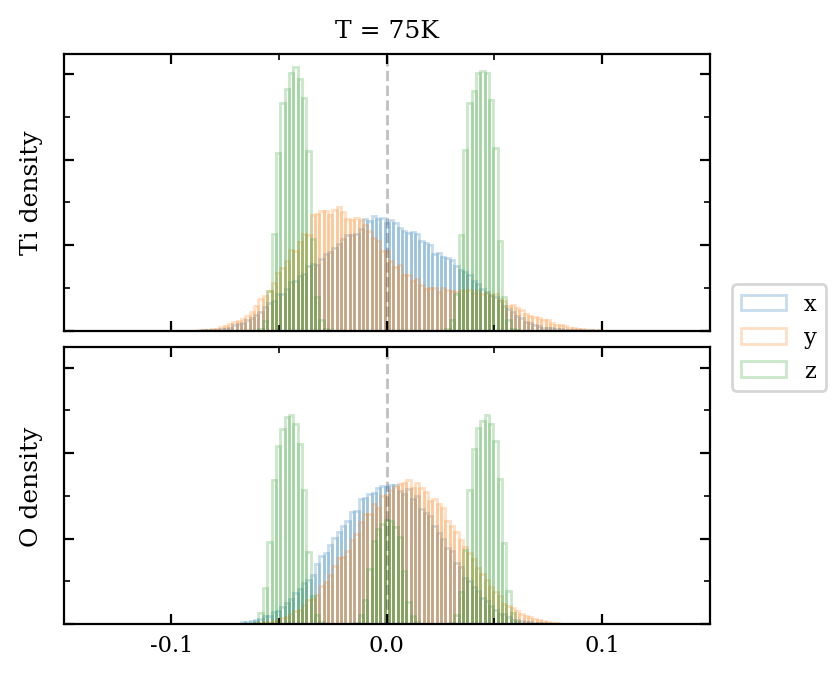

In [16]:
fig = plot_hist_and_time_series(frac_in_uc_bulk, delta=0.1, skipinds=125, bulk=True, AR=0.4, width=0.8)

In [17]:
def plot_densities(all_frac_in_uc,
                    delta=0.05, skipinds=100,
                    nx=200, ny=200, nz=200,
                    width=1, AR=1):

    temperatures = list(all_frac_in_uc.keys())
    N = len(temperatures)

    lf = LatexFigure()
    fig, axes = lf.create(subplots=(3, N), width=width, AR=AR, sharex=True, sharey='row')

    axes = np.asarray(axes).ravel()

    center = np.array([0.5, 0.5, 0.5])

    edges = [
        np.linspace(-delta, delta, nx + 1),
        np.linspace(-delta, delta, ny + 1),
        np.linspace(-delta, delta, nz + 1),
    ]

    for i, temp in enumerate(temperatures):

        # Ti density
        f_ti = all_frac_in_uc[temp]['Ti'][skipinds:, :, :].reshape(-1, 3)
        df_ti = f_ti - center

        mask_ti = np.all(np.abs(df_ti) <= delta, axis=1)
        df_ti = df_ti[mask_ti]

        density_ti, _ = np.histogramdd(df_ti, bins=edges)
        density_ti = gaussian_filter(density_ti, sigma=2.0)
        if density_ti.max() > 0:
            density_ti /= density_ti.max()

        # O density
        f_o = all_frac_in_uc[temp]['O'][skipinds:, :, :].reshape(-1, 3)
        df_o = f_o - center

        mask_o = np.all(np.abs(df_o) <= delta, axis=1)
        df_o = df_o[mask_o]

        density_o, _ = np.histogramdd(df_o, bins=edges)
        density_o = gaussian_filter(density_o, sigma=2.0)
        if density_o.max() > 0:
            density_o /= density_o.max()
        
        # Combined density
        #density = density_o - density_ti
        density = density_ti
        #vmax = np.max(np.abs(density))

        # XY slice at z=0
        axes[i].imshow(
            density[:, :, nz // 2].T,
            origin="lower",
            extent=[-delta*1.5, delta*1.5, -delta*1.5, delta*1.5],
            cmap="Blues",
            aspect="equal"
        )

        # YZ slice at x=0
        axes[i + N].imshow(
            density[nx // 2, :, :].T,
            origin="lower",
            extent=[-delta*1.5, delta*1.5, -delta*1.5, delta*1.5],
            cmap="Blues",
            aspect="equal"
        )

        # XZ slice at y=0
        axes[i + 2*N].imshow(
            density[:, ny // 2, :].T,
            origin="lower",
            extent=[-delta*1.5, delta*1.5, -delta*1.5, delta*1.5],
            cmap="Blues",
            aspect="equal"
        )
        axes[i].set_title(f'T = {temp}')

        axes[i].axhline(0, color="k", alpha=0.25, ls="--", lw=1)
        axes[i].axvline(0, color="k", alpha=0.25, ls="--", lw=1)

        axes[i + N].axhline(0, color="k", alpha=0.25, ls="--", lw=1)
        axes[i + N].axvline(0, color="k", alpha=0.25, ls="--", lw=1)

        axes[i + 2*N].axhline(0, color="k", alpha=0.25, ls="--", lw=1)
        axes[i + 2*N].axvline(0, color="k", alpha=0.25, ls="--", lw=1)

    ticks = np.linspace(-delta, delta, 3)


    axes[0].set_xlabel(r"X")
    axes[0].set_ylabel(r"Y")

    axes[N].set_xlabel(r"Y")
    axes[N].set_ylabel(r"Z")
    
    axes[2*N].set_xlabel(r"X")
    axes[2*N].set_ylabel(r"Z")

    #axes[0].set_yticks([])
    axes[0].set_xticks(ticks, ticks.astype(str))

    axes[0].set_yticks(ticks, ticks.astype(str))
    axes[N].set_yticks(ticks, ticks.astype(str))
    axes[2*N].set_yticks(ticks, ticks.astype(str))

    fig.set_constrained_layout_pads(hspace=0.0, wspace=0.0, h_pad=0.0, w_pad=0.0)

    return fig

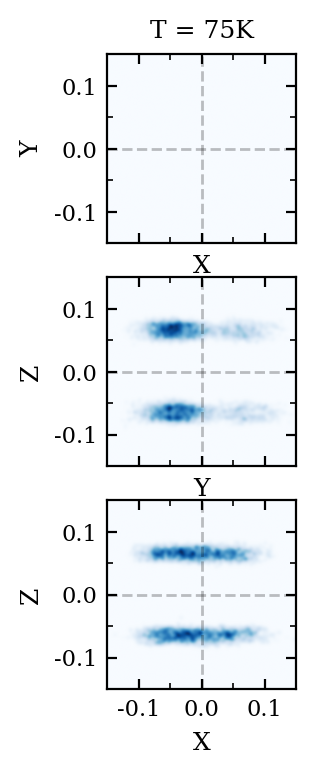

In [25]:
fig = plot_densities(frac_in_uc_bulk, delta=0.1, skipinds=125, width=0.6, AR=0.4)